In [1]:
import os, time

import math
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import newton

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# -1. Directory setup

In [3]:
plot_dir7 = "../../collected_results/figures/2.multi/"
data_dir7 = "../../data/2.multi/"

os.system("mkdir -p " + plot_dir7)
os.system("mkdir -p " + data_dir7)

0

# 6. Multilayer

In [4]:
def mu1(sigma_W, sigma_Z, trained=0):
    if trained:
        return sigma_Z**2 / 4 # Trained
    else:
        return 0.

def mu2(sigma_W, sigma_Z, trained=0):
    if trained:
        return sigma_Z**2 * (np.pi*sigma_W - 1) / (2 * np.pi * sigma_W) # Trained
    else:
        return 0.5*sigma_W**2 # Untrained

def epsilon_0_multi(sigma_W, sigma_Z, trained=0):
    return 1./mu2(sigma_W, sigma_Z, trained=trained)

def epsilon_c_multi(sigma_W, sigma_Z, r, trained=0):
    return 1./(mu2(sigma_W, sigma_Z, trained=trained) + mu1(sigma_W, sigma_Z, trained=trained)/(sigma_W * r**(0.25)))

In [5]:
def lines(mu1_bar, mu1_tilde, mu2_bar, mu2_tilde, sigma, r = 0.5):
    c2 = (mu2_tilde * (mu2_tilde + 2 * mu2_bar) * r * sigma**2 
          - mu2_bar**2 * np.sqrt(r) * sigma**2 
          + (mu1_bar + mu1_tilde)**2)
    c1 = 2. * (mu2_bar * np.sqrt(r) - mu2_tilde * r) * sigma**2
    c0 = - np.sqrt(r) * sigma**2
    
    eps_c_p = (-c1 + np.sqrt(c1**2 - 4 * c2 * c0))/(2. * c2)
    eps_c_n = (-c1 - np.sqrt(c1**2 - 4 * c2 * c0))/(2. * c2)
    eps_o = 1./mu2_bar
    
    eps_c_p = np.where(eps_c_p > 0, eps_c_p, np.nan)
    eps_c_n = np.where(eps_c_n > 0, eps_c_n, np.nan)
    eps_o = np.where(eps_o > 0, eps_o, np.nan)
    return eps_c_p, eps_c_n, eps_o

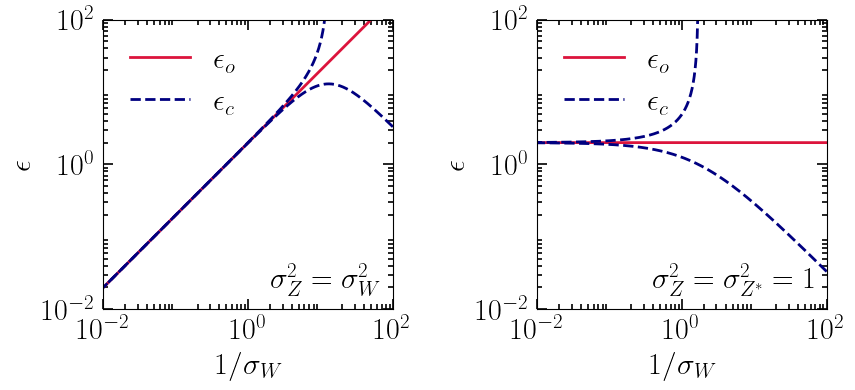

In [7]:
set_rc(scale=1.2)
r = 0.5

sigma_list = np.logspace(-2, 2, 10000)

n_fig = 2
fig, axs = plt.subplots(1, n_fig, 
                        figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']))

overlap = 1./100.

epsilon_c_list = []
epsilon_c_n_list = []
epsilon_o_list = []

for sig in sigma_list:  
    sigma_Z = sig

    mu1_bar = 1./4 * overlap
    mu2_bar = 0.5 * sigma_Z

    eps_c_p, eps_c_n, eps_o = lines(
        mu1_bar, 0., mu2_bar, 0., sig, r=0.5
    )

    epsilon_c_list.append(eps_c_p)
    epsilon_c_n_list.append(eps_c_n)
    epsilon_o_list.append(eps_o)

epsilon_c_list = np.array(epsilon_c_list)
epsilon_c_n_list = np.array(epsilon_c_n_list)
epsilon_o_list = np.array(epsilon_o_list)

axs[0].plot(
    1./sigma_list, epsilon_o_list, 
    color='crimson', marker='', ls='-', lw=2,
    label=r"$\epsilon_o$"
)

axs[0].plot(
    1./sigma_list, epsilon_c_list, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[0].plot(
    1./sigma_list, epsilon_c_n_list, 
    color='navy', marker='', ls='--', lw=2,
)

nice_style(axs[0],
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$",
           xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
          )

axs[0].text(0.58, 0.1,
            transform=axs[0].transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$\sigma_Z^2 = \sigma_W^2$",
           )

axs[0].set_aspect("equal", adjustable="box")

#######

overlap = 1

epsilon_c_list = []
epsilon_c_n_list = []
epsilon_o_list = []

for sig in sigma_list:  
    sigma_Z = 1
#     sigma_Z = sig
#     print("sig: ", sig)

    mu1_bar = 1./4 * overlap
    mu1_tilde = 0. * overlap
    
    mu2_bar = 0.5 * sigma_Z
    mu2_tilde = 0.#- 1./(2 * np.pi * sigma_Z) * overlap

    eps_c_p, eps_c_n, eps_o = lines(
        mu1_bar, mu1_tilde, mu2_bar, mu2_tilde, sig, r=0.5
    )

    epsilon_c_list.append(eps_c_p)
    epsilon_c_n_list.append(eps_c_n)
    epsilon_o_list.append(eps_o)

epsilon_c_list = np.array(epsilon_c_list)
epsilon_c_n_list = np.array(epsilon_c_n_list)
epsilon_o_list = np.array(epsilon_o_list)

axs[1].plot(
    1./sigma_list, epsilon_o_list, 
    color='crimson', marker='', ls='-', lw=2,
    label=r"$\epsilon_o$"
)

axs[1].plot(
    1./sigma_list, epsilon_c_list, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[1].plot(
    1./sigma_list, epsilon_c_n_list, 
    color='navy', marker='', ls='--', lw=2,
)


nice_style(axs[1],
           logy=True, logx=True,
           xlim=(1e-2, 1e2), ylim=(1e-2, 1e2),
           xlabel=r"$1/\sigma_W$", ylabel=r"$\epsilon$",
           xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
          )

axs[1].text(0.4, 0.1,
            transform=axs[1].transAxes,
            horizontalalignment='left', verticalalignment='center',
            color='k', 
            s=r"$\sigma_Z^2 = \sigma_{Z^{\ast}}^2 = 1$"
           )

axs[1].set_aspect("equal", adjustable="box")

axs[0].legend(loc='upper left')
axs[1].legend(loc='upper left')

plt.tight_layout()

plt.savefig(plot_dir7+"multi_phase_boundary_all.pdf")
plt.show()